In [ ]:
import pandas as pd
import torch
import triton

In [ ]:
# nn.LSTM and Graph sometimes go oom -- drop all nans for this run to avoid misleading summary stats in describe
df1 = pd.read_parquet("../full_fp32.parquet").dropna().reset_index().query("level_0!='s5'")
df2 = pd.read_parquet("../full_bf16.parquet").dropna()
df3 = pd.read_parquet("../full_fp16.parquet").dropna().reset_index().query("level_0!='s5'")

display(df1.describe())
display(df2.describe())
display(df3.describe())


In [ ]:
# forward runtime visualisation
df_in = pd.read_parquet("../fwd_bf16.parquet").dropna()
dfr = df_in / df_in["lstm"].to_numpy().reshape(-1, 1)

df_fwd = (dfr
          ["fast"]
          .droplevel(-1)
          .unstack(-1)
)

df_fwd.columns = pd.MultiIndex.from_tuples(
    [(f"FWD_bf16: FastLSTM/nn.LSTM -- torch:{torch.__version__} -- triton:{triton.__version__} -- RTX 2000 Ada" ,f"hidden:{64 << int(c[1:])}") for c in df_fwd]
)

df_fwd.index = pd.MultiIndex.from_tuples(
    [(f"seq:{64<<int(s[1:])}", f"batch:{4 << int(b[1:])}") for s, b in df_fwd.index]
)

df_fwd = df_fwd.style.background_gradient(cmap="bwr", vmin=1-1, vmax=1+1).format("{:.2f}")

df_fwd

In [ ]:
## Manual tuning
from fastlstm.lstm import FastLSTM, PersistentLSTMfn
import torch
import torch.nn as nn 

from triton.testing import do_bench

hidden_size = 256

m = nn.LSTM(input_size=hidden_size,
           hidden_size=hidden_size,
           device="cuda",
        #    version="persistent",
           )


x = torch.randn((128, 64, hidden_size), device="cuda")

res = {}

base = {"BLOCK_SIZE_H": 32, "BLOCK_SIZE_B": 32, "BLOCK_SIZE_K": 32, "num_warps": 2, "num_stages": 1}

configs = [
    ("vanilla", base),
    ("w1", base | {"num_warps": 1} ),
    ("w4", base | {"num_warps": 4} ),
    ("s2", base | {"num_warps": 1, "num_stages": 2} ),
    ("bigK", base | {"num_warps": 1, "BLOCK_SIZE_K": 16} ),
]

ref = 4.5522597537321206

for n, c in configs:
    PersistentLSTMfn.BWD_TRITON_CONFIG = c
    res[n] = do_bench(lambda : m(x)[0].sum().backward())/ref
    PersistentLSTMfn.BWD_TRITON_CONFIG = None

# 1.197

In [ ]:
from torch.amp import autocast
from fastlstm.lstm import FastLSTM, PersistentLSTMfn
import torch
import torch.nn as nn 

from triton.testing import do_bench

hidden_size = 256
x = torch.randn((1, 8, hidden_size), device="cuda")


if False:
    m = nn.LSTM(input_size=hidden_size,
            hidden_size=hidden_size,
            device="cuda",
            #    version="persistent",
            )
else:
    m = FastLSTM(input_size=hidden_size,
                 hidden_size=hidden_size,
                 device="cuda",
                 version="persistent",
                 )

def fn(dtype):
    dd = {
        "fp32": None,
        "fp16": torch.float16,
        "bf16": torch.bfloat16
    }
    with autocast("cuda", dd[dtype], enabled=dtype!="fp32"):
        m(x)[0].sum().backward()
        
y = x + 12
with autocast("cuda", torch.float16):
    print(y.dtype)
    t = m(y)[0]
    print(t.dtype)
    t.sum().backward()
    for n, p in m.named_parameters():
        print(n, p.dtype, p.grad.dtype)
    print(y.dtype)
    

In [ ]:
import pandas as pd

ax = (pd.DataFrame(res, columns=["batch_size", "nn.LSTM", "persistent", "graph", "cuda_fused", "cuda"])
 .set_index("batch_size")
 [["nn.LSTM", "graph", "persistent", "Flash:alternating", "Flash:fused"]]
 .plot(kind="bar", ylabel="mean runtime [ms]", title="fp16 FWD pass on H100 -- seq=1024, hidden=768", grid=True)
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

ax


<Axes: >

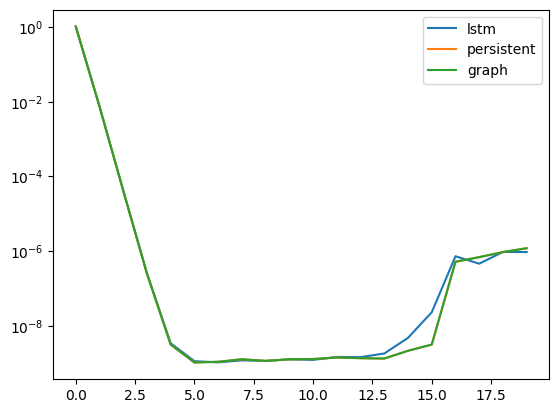

In [7]:
# visualise overfit losses
import pandas as pd

df = pd.read_parquet("../bf16_losses.parquet")
df.plot(logy=True)


In [129]:
from collections import defaultdict
import json
import re

import numpy as np
import pandas as pd

with open("../tuning_full_fp16.json") as fh:
    data = json.load(fh)

res = defaultdict(list)

for setting, configs in data.items():
    for config, perf in configs:
        if setting.startswith("persistent"):
            try:
                matches = re.findall("BLOCK_SIZE_K: ([0-9]+), batch_chunks: [0-9]+, num_pid_b: [0-9]+, BLOCK_SIZE_B: ([0-9]+), BLOCK_SIZE_H: ([0-9]+), num_warps: ([0-9]+), num_ctas: 1, num_stages: ([0-9]+), maxnreg: None", config)
                assert len(matches) == 1
                k, h, b, w, s = (int(e) for e in matches[0])
                res[(setting, h, b ,k, w, s)] += [perf[0]]

            except:
                matches = re.findall("BLOCK_SIZE_K: ([0-9]+), BLOCK_SIZE_H: ([0-9]+), BLOCK_SIZE_B: ([0-9]+), num_pid_h: ([0-9]+), num_pid_b: ([0-9]+), num_warps: ([0-9]+), num_ctas: 1, num_stages: ([0-9]+), maxnreg: None", config)
                assert len(matches) == 1
                k, h, b, nh, nb, w, s = (int(e) for e in matches[0])

                res[(setting, h, b ,k, nh, nb, w, s)] += [perf[0]]

        else:
            matches = re.findall("BLOCK_SIZE_H: ([0-9]+), BLOCK_SIZE_B: ([0-9]+), BLOCK_SIZE_K: ([0-9]+), GROUP_SIZE_B: ([0-9]+), num_warps: ([0-9]+), num_ctas: 1, num_stages: ([0-9]+), maxnreg: None", config)
            assert len(matches) == 1
            h, b, k, g, w, s = (int(e) for e in matches[0])
            
            res[(setting, h, b ,k, g, w, s)] += [perf[0]]

for k, v in res.items():
    res[k] = np.array(v).mean()


raw = (pd.DataFrame(res, index=["val"])
 .stack(0)
 .T
 .droplevel(0, axis=1)
)


best = pd.concat([raw.idxmin(), 1_000*raw.min()], axis=1, keys=["config", "time"])
best.index = pd.MultiIndex.from_tuples([tuple(ii.split("-")) for ii in best.index])

best = best.droplevel(-1)


/tmp/ipykernel_117919/2160034668.py:41: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(0)


In [135]:
ddf = raw.T
ddf.index = pd.MultiIndex.from_tuples([tuple(ii.split("-")) for ii in ddf.index])


In [149]:
times = ddf.loc[("persistentBWD")].droplevel(-1).T

rr = times.replace({np.inf: np.nan})/times.min()


rr.describe(percentiles=[0.01, 0.03, 0.05, 0.1]).T.sort_values(by="10%")


count      mean       std  min        1%        3%        5%  \
h128  b4     24.0  1.843952  0.792996  1.0  1.000000  1.000000  1.000872   
h2048 b4     14.0  1.540310  0.446509  1.0  1.000685  1.002055  1.003425   
h64   b16     8.0  1.080126  0.099872  1.0  1.000644  1.001933  1.003222   
h512  b4     24.0  1.393828  0.364368  1.0  1.001357  1.004072  1.006316   
h2048 b32    36.0  2.146253  1.053216  1.0  1.001823  1.005260  1.005977   
h1024 b8     30.0  6.538045  3.894563  1.0  1.000399  1.001196  1.005498   
      b16    24.0  1.517373  0.566612  1.0  1.001235  1.003704  1.006785   
h256  b4     24.0  1.793080  0.689240  1.0  1.001114  1.003343  1.006107   
h64   b32    24.0  1.274341  0.275747  1.0  1.002545  1.007636  1.011423   
h2048 b8     22.0  4.258511  2.867075  1.0  1.000696  1.002088  1.004333   
      b16    22.0  1.373723  0.434320  1.0  1.004882  1.014647  1.023417   
h1024 b64    68.0  2.231747  1.587340  1.0  1.001139  1.002932  1.005147   
h128  b16    24.0  1.346246  0.347331  1.0  1.003607  1.010822  1.017472   
h64   b4     16.0  1.382285  0.332770  1.0  1.003451  1.010353  1.017255   
h256  b16    24.0  1.451727  0.479522  1.0  1.007470  1.022410  1.033761   
h128  b32    48.0  1.718414  0.648178  1.0  1.009557  1.026956  1.038158   
h256  b32    48.0  1.671313  0.719630  1.0  1.016315  1.035015  1.038294   
h2048 b64    50.0  3.593834  2.579680  1.0  1.000204  1.001997  1.005086   
h64   b8     24.0  1.955723  0.832480  1.0  1.006226  1.018678  1.031477   
h2048 b128   60.0  4.250671  2.900833  1.0  1.002124  1.004774  1.011391   
h128  b8     40.0  3.404184  2.389542  1.0  1.002664  1.007643  1.011373   
h1024 b4     22.0  1.542092  0.412172  1.0  1.013309  1.039927  1.064100   
h512  b16    24.0  1.534330  0.547752  1.0  1.005924  1.017771  1.033779   
h128  b64    80.0  1.995244  1.033733  1.0  1.008404  1.030719  1.071986   
h512  b128  108.0  2.310323  1.561738  1.0  1.005257  1.027982  1.046138   
h64   b64    48.0  1.620102  0.531258  1.0  1.000000  1.017554  1.056277   
h1024 b32    46.0  1.969115  0.869277  1.0  1.002948  1.012148  1.040173   
      b128   90.0  4.503923  5.320419  1.0  1.010479  1.030517  1.043726   
h256  b64    80.0  1.897578  1.027625  1.0  1.005142  1.019941  1.024231   
h128  b128  120.0  2.247740  1.412893  1.0  1.005079  1.009121  1.068107   
h256  b8     40.0  4.283748  2.735943  1.0  1.020995  1.060657  1.091971   
h512  b32    48.0  1.888418  0.834944  1.0  1.015408  1.060580  1.107449   
      b8     38.0  5.683402  3.136437  1.0  1.008446  1.028745  1.068560   
      b64    78.0  2.144286  1.101232  1.0  1.009299  1.057301  1.068601   
h64   b128   80.0  2.126916  0.949226  1.0  1.003638  1.043921  1.114638   
h256  b128  118.0  2.278884  1.432541  1.0  1.018525  1.098479  1.118949   

                 10%       50%        max  
h128  b4    1.006105  1.640262   2.950581  
h2048 b4    1.006436  1.900281   1.934358  
h64   b16   1.006443  1.035983   1.250209  
h512  b4    1.009939  1.274479   1.854877  
h2048 b32   1.012388  1.860279   4.438781  
h1024 b8    1.014662  7.554868  12.996678  
      b16   1.015266  1.337144   3.078261  
h256  b4    1.015400  1.544238   2.759052  
h64   b32   1.016047  1.175494   1.916206  
h2048 b8    1.023819  4.096174   7.676665  
      b16   1.026695  1.068710   2.005622  
h1024 b64   1.031070  1.692214   9.305114  
h128  b16   1.034379  1.290464   2.254705  
h64   b4    1.038727  1.383436   1.808282  
h256  b16   1.045897  1.310684   2.756410  
h128  b32   1.056340  1.559809   3.815789  
h256  b32   1.056721  1.454764   4.258124  
h2048 b64   1.057013  2.665655   9.851037  
h64   b8    1.063418  1.738592   3.316319  
h2048 b128  1.069024  2.773108  10.320233  
h128  b8    1.069672  2.383538   7.859289  
h1024 b4    1.079806  1.448925   2.307668  
h512  b16   1.081253  1.360575   2.979445  
h128  b64   1.090527  1.590172   6.101317  
h512  b128  1.095342  1.920801   9.657290  
h64   b64   1.099927  1.501451   3.150943  
h1024 b32  

In [131]:
for n, grp in best.groupby(level=[0]):
    display(n, grp["config"].value_counts())

/tmp/ipykernel_117919/640444959.py:1: FutureWarning: Creating a Groupby object with a length-1 list-like level parameter will yield indexes as tuples in a future version. To keep indexes as scalars, create Groupby objects with a scalar level parameter instead.
  for n, grp in best.groupby(level=[0]):


'graph'

config
(8, 8, 64, 8, 1, 4.0)      11
(16, 64, 64, 8, 4, 4.0)     6
(8, 32, 64, 8, 2, 4.0)      5
(8, 8, 64, 8, 1, 6.0)       5
(8, 16, 64, 8, 1, 6.0)      2
(8, 8, 64, 8, 1, 8.0)       1
(8, 64, 64, 8, 4, 8.0)      1
(16, 16, 64, 8, 2, 4.0)     1
(16, 64, 32, 8, 2, 4.0)     1
(8, 8, 32, 8, 1, 4.0)       1
(8, 8, 32, 8, 1, 8.0)       1
(8, 8, 32, 8, 1, 6.0)       1
Name: count, dtype: int64

'persistent'

config
(32, 64, 32, 4, 4, nan)     5
(16, 64, 32, 4, 4, nan)     4
(16, 32, 32, 4, 4, nan)     3
(1, 32, 32, 4, 2, nan)      2
(1, 256, 32, 4, 2, nan)     2
(8, 32, 32, 4, 4, nan)      2
(8, 16, 32, 2, 4, nan)      2
(64, 128, 32, 4, 2, nan)    2
(8, 8, 32, 2, 4, nan)       2
(16, 8, 32, 2, 6, nan)      1
(8, 64, 32, 4, 4, nan)      1
(16, 32, 32, 4, 6, nan)     1
(32, 8, 32, 2, 4, nan)      1
(8, 128, 32, 2, 2, nan)     1
(32, 128, 32, 4, 2, nan)    1
(16, 128, 32, 2, 2, nan)    1
(1, 64, 32, 4, 4, nan)      1
(1, 128, 32, 4, 2, nan)     1
(64, 32, 32, 4, 4, nan)     1
(8, 32, 32, 4, 6, nan)      1
(1, 16, 32, 2, 2, nan)      1
Name: count, dtype: int64

'persistentBWD'

config
(16, 64, 32, 4, 6, nan)     2
(32, 64, 32, 4, 6, nan)     2
(8, 64, 32, 4, 8, nan)      2
(1, 256, 32, 4, 2, nan)     2
(8, 16, 32, 2, 6, nan)      2
(32, 64, 32, 4, 8, nan)     2
(64, 64, 32, 4, 6, nan)     1
(8, 128, 32, 4, 4, nan)     1
(8, 32, 32, 4, 6, nan)      1
(1, 32, 32, 2, 2, nan)      1
(8, 64, 32, 4, 4, nan)      1
(8, 8, 32, 2, 8, nan)       1
(64, 128, 32, 4, 8, nan)    1
(32, 128, 32, 4, 4, nan)    1
(16, 128, 32, 4, 8, nan)    1
(32, 128, 32, 4, 8, nan)    1
(64, 128, 32, 4, 6, nan)    1
(8, 128, 32, 4, 8, nan)     1
(8, 32, 32, 2, 8, nan)      1
(1, 64, 32, 4, 6, nan)      1
(8, 16, 32, 2, 8, nan)      1
(16, 32, 32, 4, 8, nan)     1
(32, 32, 32, 4, 8, nan)     1
(1, 128, 32, 4, 2, nan)     1
(8, 32, 32, 4, 8, nan)      1
(8, 64, 32, 4, 6, nan)      1
(8, 8, 32, 2, 6, nan)       1
(1, 16, 32, 2, 6, nan)      1
(8, 32, 32, 4, 4, nan)      1
(1, 32, 32, 4, 6, nan)      1
Name: count, dtype: int64

In [122]:
best1["config"].shape

(72,)

In [123]:
best1["config"]

persistent-h1024-b128-fp16    (32, 64, 32, 4, 4)
persistent-h1024-b16-fp16     (16, 64, 32, 4, 4)
persistent-h1024-b32-fp16     (32, 64, 32, 4, 4)
persistent-h1024-b4-fp16      (1, 256, 32, 4, 2)
persistent-h1024-b64-fp16     (32, 64, 32, 4, 4)
                                     ...        
persistentBWD-h64-b16-fp16      (8, 8, 32, 2, 6)
persistentBWD-h64-b32-fp16     (8, 16, 32, 2, 6)
persistentBWD-h64-b4-fp16      (1, 16, 32, 2, 6)
persistentBWD-h64-b64-fp16     (8, 32, 32, 4, 4)
persistentBWD-h64-b8-fp16      (1, 32, 32, 4, 6)
Name: config, Length: 72, dtype: object

In [4]:
pd.read_parquet("../full_fp16bench.parquet")

,,,,lstm,persistent,cuda,cuda_fused,triton_fused
s64,b128,h2048,l1,58.956192,91.028259,56.186720,NaN,NaN
s128,b128,h2048,l1,115.415459,185.001190,108.197090,NaN,NaN
s256,b128,h2048,l1,233.042496,374.905426,212.429565,NaN,NaN
s512,b128,h2048,l1,469.406555,763.257446,425.226044,NaN,NaN
s64,b128,h1024,l1,14.402240,18.192480,15.254208,NaN,NaN
...,...,...,...,...,...,...,...,...
s512,b4,h128,l1,1.824192,3.336800,16.809759,2.357792,NaN
s64,b4,h64,l1,0.128832,0.514304,3.897312,1.830768,NaN
s128,b4,h64,l1,0.299168,0.517344,4.320000,1.914816,NaN
s256,b4,h64,l1,0.343840,0.992000,10.679200,2.100224,NaN


In [5]:
pd.read_parquet("../full_fp16bench.parquet").to_parquet("../figures/raw_data/full_fp16_persistent_flash.parquet")


In [ ]:
df_in = pd.read_parquet("../bwd_fp16.parquet")
(df_in/ df_in["persistent"].to_numpy().reshape(-1, 1)).round(2)["graph"].unstack(-2).droplevel(0)

# so: b4 and leq 512 for bwd

,,h1024,h128,h2048,h256,h512,h64
b128,l1,1.05,1.36,0.93,1.21,1.10,1.69
b16,l1,1.22,3.10,1.05,1.72,1.34,4.37
b32,l1,1.26,1.96,1.07,1.35,1.31,3.64
b4,l1,0.34,1.80,0.52,1.11,0.43,3.48
b64,l1,1.07,1.70,0.98,1.28,1.27,2.38
b8,l1,1.12,3.46,1.03,2.39,1.44,2.97


In [99]:
df_in

graph   persistent        lstm       triton         fast
s0 b0 h0 l0     3.604544     0.324544    0.430784     0.304160     0.324544
      h1 l0     3.710096     0.435904    0.356320     0.360192     0.435904
      h2 l0     4.284800     0.556608    2.726048     0.559648     0.556608
      h3 l0     5.038432     1.209712    3.113952     1.209760     1.209712
      h4 l0     6.210448     4.013872    3.328144     4.941504     4.013872
...                  ...          ...         ...          ...          ...
s4 b5 h1 l0    31.226528    21.277887    8.452736    22.909376    21.277887
      h2 l0    49.567265    45.105022   32.775759    46.997215    45.105022
      h3 l0   111.380798   122.068253   79.196861   112.652130   111.380798
      h4 l0   344.354340   399.515594  238.272064   335.523804   344.354340
      h5 l0  1243.100220  2168.625488  956.358154  1219.330566  1243.100220

[180 rows x 5 columns]

In [ ]:
df_in = pd.read_parquet("../full_fp16.parquet")
# df_in = pd.read_parquet("../figures/raw_data/fwd_fp16.parquet")
df_in = pd.read_parquet("../figures/raw_data/full_fp16.parquet")

               
df_in["fast"] = df_in[["persistent", "graph"]].min(axis=1)
# df_in["flash"] = df_in[["cuda", "cuda_fused", "triton_fused"]].min(axis=1)
dfr = df_in / df_in["lstm"].to_numpy().reshape(-1, 1)
dfr["lstm"] = df_in["lstm"]

dfr.index = pd.MultiIndex.from_tuples(
    [(int(ii[0][1:]), int(ii[1][1:]), int(ii[2][1:]), int(ii[3][1:])) for ii in dfr.index],
    names=["seq", "batch", "hidden", "layer"]
)

rn = {"fast": "fast/lstm",
    #   "flash": "flash/lstm",
      "lstm": "lstm[ms]",
      "graph": "graph/lstm",
      "persistent": "persistent/lstm"
      }

(dfr
 [["graph", "persistent", "fast",
#    "flash", "lstm"
   ]]
 .rename(columns=rn)
 .droplevel(-1, axis=0)
 .unstack(-1)
 .style
 .background_gradient(cmap="bwr", vmin=1-1, vmax=1+1, subset=[v for v in rn.values() if not v.startswith("lstm")])
 .format("{:.2f}")
)


KeyError: "None of [Index(['cuda', 'cuda_fused', 'triton_fused'], dtype='object')] are in the [columns]"

In [97]:
import math

res = {}

for b in [128, 64, 32, 16, 8]:
    for h in [256, 512, 1024, 2048]:
        res[(b, h)] = math.log2(b)/6 + math.log2(h)/10


pd.DataFrame(res, index=["v"]).stack(0).round(2)

/tmp/ipykernel_117919/2591803067.py:10: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  pd.DataFrame(res, index=["v"]).stack(0).round(2)


256   512   1024  2048
v 8    1.30  1.40  1.50  1.60
  16   1.47  1.57  1.67  1.77
  32   1.63  1.73  1.83  1.93
  64   1.80  1.90  2.00  2.10
  128  1.97  2.07  2.17  2.27

In [ ]:
import pandas as pd

df = (
    pd.read_parquet("../figures/raw_data/h100_fwd_fp16.parquet")
    .droplevel([0, 2, 3])
)

df.index = [int(i[1:]) for i in df.index]

ax = (
    df    
    .sort_index()
    [["lstm", "persistent", "graph", "cuda", "cuda_fused"]]
    .plot(kind="bar", ylabel="mean runtime [ms]", title="fp16 FWD pass on H100 -- seq=1024, hidden=768", grid=True)
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

ax
